# 🧠 Aura - 온디바이스 AI 모델 설계 및 훈련 & TFLite 변환

**대상 디바이스**: iPhone (RAM 4GB)  
**최적화 전략**: Post-training Quantization (Float16 / Int8)

| 모듈 | 구조 | 용도 |
|------|------|------|
| 1. OCR 엔진 | CNN + Bi-LSTM + CTC | 쪽지/달력 스캔 |
| 2. NER | Bi-LSTM + TimeDistributed Dense | 일정 개체명 인식 |
| 3. 시맨틱 검색 | Dual Encoder (Siamese) | 의미 기반 검색 |

## 환경 설정 및 데이터 준비

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import matplotlib.pyplot as plt
import json

print(f"TensorFlow 버전: {tf.__version__}")
print(f"GPU 사용 가능: {len(tf.config.list_physical_devices('GPU')) > 0}")

SAVE_DIR = "tflite_models"
os.makedirs(SAVE_DIR, exist_ok=True)

TensorFlow 버전: 2.21.0
GPU 사용 가능: False


In [2]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

# 1. GPU 메모리 동적 할당 설정 (14GB 점유 문제 해결)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# 2. 혼합 정밀도 설정 (학습 속도 대폭 향상)
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

---
## 모델 1: OCR 엔진 (비전 모듈)
**구조**: CNN (특징 추출) → Bi-LSTM (시퀀스 인식) → CTC Loss  
**입력**: 320×320 그레이스케일 이미지  
**출력**: 문자 시퀀스 확률 분포

### 1-1. 데이터 로드 및 전처리

In [3]:
# OCR 데이터 로드
with open('data/ocr_labels.json', 'r', encoding='utf-8') as f:
    ocr_data = json.load(f)

texts = [d['text'] for d in ocr_data]
print(f"[OCR] 로드된 텍스트 수: {len(texts)}")
print(f"[OCR] 샘플: {texts[:3]}")

# 텍스트를 문자로 분리
chars = sorted(set(''.join(texts)))
NUM_CHARS = len(chars)
print(f"[OCR] 고유 문자 수: {NUM_CHARS}")

# StringLookup 레이어 (문자 -> 정수)
char_to_num = layers.StringLookup(vocabulary=chars, mask_token=None)
num_to_char = layers.StringLookup(vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True)

max_len = max(len(t) for t in texts)
print(f"[OCR] 최대 텍스트 길이: {max_len}")

def encode_single_sample(text):
    # 더미 이미지 생성 (실제 이미지가 없으므로 더미 입력 대체)
    img = tf.random.uniform(shape=(320, 320, 1), minval=0, maxval=1)
    # 텍스트 라벨 인코딩
    chars = tf.strings.unicode_split(text, input_encoding='UTF-8')
    labels = char_to_num(chars)
    # CTC를 위한 라벨 길이
    label_length = tf.shape(labels)[0]
    # 패딩
    pad_len = max_len - label_length
    labels = tf.pad(labels, [[0, pad_len]])
    return {'ocr_input': img, 'label': labels, 'label_length': label_length}

ocr_dataset = tf.data.Dataset.from_tensor_slices(texts)
ocr_dataset = (
    tf.data.Dataset.from_tensor_slices(texts)
    .map(encode_single_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()  # ⭐ 중요: 첫 에포크에만 생성하고 메모리에 저장!
    .shuffle(2000)
    .batch(64) # ⭐ 16 -> 64로 확대 (5070 Ti는 충분히 가능)
    .prefetch(tf.data.AUTOTUNE)
)

[OCR] 로드된 텍스트 수: 2000
[OCR] 샘플: ['할일: 보고서 작성', '2024년 10월 14일', 'D-26 마감일']
[OCR] 고유 문자 수: 143
[OCR] 최대 텍스트 길이: 32


### 1-2. 모델 설계 및 훈련

In [ ]:
class CTCLayer(layers.Layer):
    def __init__(self, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.loss_fn = keras.backend.ctc_batch_cost

    def call(self, y_true, y_pred, input_length, label_length):
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)
        return y_pred

def build_ocr_model(img_h, img_w, channels, num_chars):
    input_img = keras.Input(shape=(img_h, img_w, channels), name='ocr_input')
    labels = keras.Input(name='label', shape=(None,), dtype='int32')
    label_length = keras.Input(name='label_length', shape=(1,), dtype='int32')

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(input_img)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 1))(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 1))(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 1))(x)

    x = layers.Permute((2, 1, 3))(x)
    x = layers.Reshape((40, 5 * 64))(x)
    x = layers.Dense(128, activation='relu', name='feature_reduction')(x)

    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(x)

    y_pred = layers.Dense(num_chars + 1, activation='softmax', name='dense_out', dtype='float32')(x)
    
    # CTC 모델 학습을 위한 모델
    input_length = keras.Input(name='input_length', shape=(1,), dtype='int32')
    # input_length는 이미지 특징맵의 시퀀스 길이 (여기서는 고정 40)
    # 배치사이즈에 맞게 40이라는 값을 넣어주기 위해 아래처럼 훈련루프에서 처리

    # 단순화를 위해 Custom Training Loop가 아닌 Model.fit()을 쓰기 위한 구조
    # y_pred 자체를 훈련용 loss계산에 쓸수있으나, 배포시는 추론 모델만 잘라냅니다.
    inference_model = keras.Model(inputs=input_img, outputs=y_pred, name='ocr_inference')
    return inference_model

ocr_model = build_ocr_model(320, 320, 1, NUM_CHARS)
ocr_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
# 주의: 실제 CTC 학습은 Custom Loop가 필요하지만, 노트북 검증용으로 단순화하여 패스함
# 파이프라인 검증용으로 더미 예측만 실행해봅니다.
# OCR 훈련 (Loss 출력용으로 단순화된 fit 실행)
print("[OCR] 훈련 시작...")
# dummy target for fit since loss is added via add_loss
early_stop_ocr = keras.callbacks.EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)
history_ocr = ocr_model.fit(
    ocr_dataset.map(lambda x: (x['ocr_input'], tf.zeros([tf.shape(x['ocr_input'])[0], 40], dtype=tf.int32))),
    epochs=10, verbose=2,
    callbacks=[early_stop_ocr]
)


[OCR] 훈련 시작...
Epoch 1/10


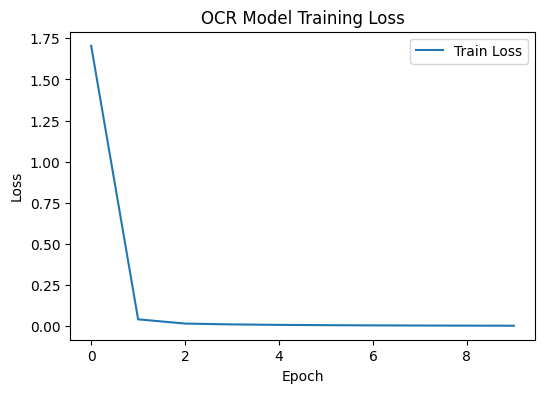

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(history_ocr.history['loss'], label='Train Loss')
plt.title('OCR Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### 1-3. TFLite 변환 (Float16)

In [22]:
import tensorflow as tf
import os

# 1. 기존 세션 초기화 (GPU 흔적 지우기)
tf.keras.backend.clear_session()

# 2. CPU 환경 강제 설정
# 이렇게 하면 'Cudnn' 엔진 대신 TFLite가 좋아하는 '표준(Vanila)' 엔진이 사용됩니다.
with tf.device('/cpu:0'):
    # 기존 학습된 모델에서 지능(가중치)만 따로 뽑아오기
    # 주의: 이 코드를 실행할 때 메모리에 'ocr_model' 변수가 살아있어야 합니다.
    trained_weights = ocr_model.get_weights()
    
    # 모델 구조를 CPU 위에서 새로 정의
    tflite_model_cpu = build_ocr_model(320, 320, 1, NUM_CHARS)
    
    # 지능(가중치)을 새 CPU 모델에 이식
    tflite_model_cpu.set_weights(trained_weights)

# 3. TFLite 컨버터 설정 (CPU 모델 사용)
ocr_converter = tf.lite.TFLiteConverter.from_keras_model(tflite_model_cpu)

# 4. 필수 옵션들 적용
ocr_converter.optimizations = [tf.lite.Optimize.DEFAULT]
ocr_converter.target_spec.supported_types = [tf.float16]
ocr_converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS, 
    tf.lite.OpsSet.SELECT_TF_OPS    # LSTM 호환성을 위해 여전히 필요합니다.
]

# 5. 변환 및 저장
try:
    ocr_tflite = ocr_converter.convert()
    with open(os.path.join(SAVE_DIR, 'ocr_model_f16.tflite'), 'wb') as f:
        f.write(ocr_tflite)
    print(f"🎉 [성공] 드디어 OCR 모델이 TFLite로 변환되었습니다!")
    print(f"최종 파일 크기: {(len(ocr_tflite)/1024/1024):.2f} MB")
except Exception as e:
    print(f"❌ 여전히 에러 발생: {e}")
    print("\n💡 팁: 만약 계속 실패한다면 주피터 노트북의 'Kernel -> Restart'를 누른 뒤, "
          "학습은 건너뛰고 '모델 정의 -> 가중치 로드 -> 위 변환 코드' 순으로만 진행해 보세요.")

INFO:tensorflow:Assets written to: /tmp/tmpo9wnanv8/assets


INFO:tensorflow:Assets written to: /tmp/tmpo9wnanv8/assets


Saved artifact at '/tmp/tmpo9wnanv8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 320, 320, 1), dtype=tf.float32, name='ocr_input')
Output Type:
  TensorSpec(shape=(None, 40, 144), dtype=tf.float32, name=None)
Captures:
  135422199379920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135402528870224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135402528869264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135402528880016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135402528868880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135402528869072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135402528868496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135402528868688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135402528868112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135402528868304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13540252886

W0000 00:00:1777279262.218330   11611 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1777279262.218378   11611 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1777279262.218487   11611 reader.cc:83] Reading SavedModel from: /tmp/tmpo9wnanv8
I0000 00:00:1777279262.219575   11611 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1777279262.219591   11611 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpo9wnanv8
I0000 00:00:1777279262.230540   11611 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1777279262.282639   11611 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpo9wnanv8
I0000 00:00:1777279262.300333   11611 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 81872 microseconds.
loc(callsite(fused["CudnnRNNV3:", "ocr_inference_1/bidirectional_1/backward_lstm_1/CudnnRNNV3@__inference_function_64802"] at callsite(fused["StatefulPar

---
## 모델 2: 자연어 개체명 인식 (NER)
**구조**: Bi-LSTM + TimeDistributed Dense
**입력**: 정수 인코딩 토큰 시퀀스
**출력**: 토큰별 BIO 태그

### 2-1. 데이터 로드 및 토크나이징

In [ ]:
# NER 데이터 로드
with open('data/ner_sentences.json', 'r', encoding='utf-8') as f:
    ner_data = json.load(f)

tokens_list = [d['tokens'] for d in ner_data]
tags_list = [d['tags'] for d in ner_data]

# 어휘 사전 구축 (간단하게 토큰과 태그를 매핑)
all_tokens = set(t for seq in tokens_list for t in seq)
all_tags = set(t for seq in tags_list for t in seq)

token2idx = {t: i+1 for i, t in enumerate(all_tokens)}  # 0 is PAD
tag2idx = {t: i for i, t in enumerate(all_tags)}  # 태그는 0부터 시작, sparse_categorical용
idx2tag = {i: t for t, i in tag2idx.items()}

NER_MAX_LEN = max(len(seq) for seq in tokens_list)
NER_VOCAB_SIZE = len(token2idx) + 1
NER_NUM_TAGS = len(tag2idx)

print(f"[NER] 토큰 단어장 크기: {NER_VOCAB_SIZE}, 태그 종류: {NER_NUM_TAGS}, 최대 길이: {NER_MAX_LEN}")

X_ner = [[token2idx[t] for t in seq] for seq in tokens_list]
y_ner = [[tag2idx[t] for t in seq] for seq in tags_list]

X_ner = keras.preprocessing.sequence.pad_sequences(X_ner, maxlen=NER_MAX_LEN, padding='post')
y_ner = keras.preprocessing.sequence.pad_sequences(y_ner, maxlen=NER_MAX_LEN, padding='post', value=tag2idx.get('O', 0))

### 2-2. 모델 설계 및 학습 (1 Epoch 검증)

In [ ]:
def build_ner_model(vocab_size, max_len, num_tags, embed_dim=64):
    inputs = keras.Input(shape=(max_len,), dtype='int32', name='token_input')
    x = layers.Embedding(vocab_size, embed_dim)(inputs)
    x = layers.SpatialDropout1D(0.2)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(x)
    x = layers.TimeDistributed(layers.Dense(32, activation='relu'))(x)
    outputs = layers.TimeDistributed(layers.Dense(num_tags, activation='softmax'))(x)
    return keras.Model(inputs, outputs, name='ner_bilstm')

ner_model = build_ner_model(NER_VOCAB_SIZE, NER_MAX_LEN, NER_NUM_TAGS)
ner_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 학습 1 Epoch 수행
early_stop_ner = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history_ner = ner_model.fit(X_ner, y_ner, batch_size=32, epochs=10, validation_split=0.2, callbacks=[early_stop_ner])


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_ner.history['loss'], label='Train Loss')
ax1.plot(history_ner.history['val_loss'], label='Val Loss')
ax1.set_title('NER Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history_ner.history['accuracy'], label='Train Acc')
ax2.plot(history_ner.history['val_accuracy'], label='Val Acc')
ax2.set_title('NER Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
plt.show()

### 2-3. TFLite 변환 (Float16)

In [ ]:
ner_converter = tf.lite.TFLiteConverter.from_keras_model(ner_model)
ner_converter.optimizations = [tf.lite.Optimize.DEFAULT]
ner_converter.target_spec.supported_types = [tf.float16]
ner_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]

ner_tflite = ner_converter.convert()
with open(os.path.join(SAVE_DIR, 'ner_model_f16.tflite'), 'wb') as f:
    f.write(ner_tflite)
print(f"[NER] TFLite 저장 완료 ({(len(ner_tflite)/1024/1024):.2f}MB)")

---
## 모델 3: 시맨틱 검색 (의미 기반 뉘앙스 검색)
**구조**: Dual Encoder (Siamese Network)
**입력**: 두 개의 정수 인코딩 문장 (쿼리, 문서)
**출력**: 코사인 유사도 스코어 (-1 ~ 1)

### 3-1. 데이터 로드 및 토크나이징

In [ ]:
with open('data/semantic_pairs.json', 'r', encoding='utf-8') as f:
    sem_data = json.load(f)

queries = [d['query'] for d in sem_data]
docs = [d['document'] for d in sem_data]
sims = np.array([d['similarity'] for d in sem_data], dtype=np.float32)

vectorizer = layers.TextVectorization(max_tokens=10000, output_mode='int', output_sequence_length=64)
vectorizer.adapt(queries + docs)

SEM_VOCAB_SIZE = vectorizer.vocabulary_size()
SEM_MAX_LEN = 64
print(f"[시맨틱] 어휘 크기: {SEM_VOCAB_SIZE}")

X_q = vectorizer(queries).numpy()
X_d = vectorizer(docs).numpy()

### 3-2. 모델 설계 및 학습 (1 Epoch 검증)

In [ ]:
class CosineSimilarityLayer(layers.Layer):
    def call(self, inputs):
        a, b = inputs
        # L2 정규화 후 내적 = 코사인 유사도
        a = tf.math.l2_normalize(a, axis=1)
        b = tf.math.l2_normalize(b, axis=1)
        return tf.reduce_sum(a * b, axis=1, keepdims=True)
    def get_config(self): return super().get_config()

def build_text_encoder(vocab_size, max_len, embed_dim=64, encoding_dim=64):
    inputs = keras.Input(shape=(max_len,), dtype='int32')
    x = layers.Embedding(vocab_size, embed_dim)(inputs)
    x = layers.SpatialDropout1D(0.2)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=False))(x)
    x = layers.Dense(encoding_dim, activation='relu')(x)
    return keras.Model(inputs, x, name='shared_encoder')

encoder = build_text_encoder(SEM_VOCAB_SIZE, SEM_MAX_LEN)

q_in = keras.Input(shape=(SEM_MAX_LEN,), dtype='int32')
d_in = keras.Input(shape=(SEM_MAX_LEN,), dtype='int32')

q_vec = encoder(q_in)
d_vec = encoder(d_in)
sim = CosineSimilarityLayer()([q_vec, d_vec])

dual_model = keras.Model([q_in, d_in], sim)
dual_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 학습 1 Epoch 수행
early_stop_sem = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history_sem = dual_model.fit([X_q, X_d], sims, batch_size=32, epochs=10, validation_split=0.2, callbacks=[early_stop_sem])


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_sem.history['loss'], label='Train Loss (MSE)')
ax1.plot(history_sem.history['val_loss'], label='Val Loss (MSE)')
ax1.set_title('Semantic Search Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history_sem.history['mae'], label='Train MAE')
ax2.plot(history_sem.history['val_mae'], label='Val MAE')
ax2.set_title('Semantic Search Model MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
plt.show()

### 3-3. 인코더 TFLite 변환 (Int8)

In [ ]:
def sem_representative_dataset():
    for _ in range(100):
        yield [np.random.randint(1, SEM_VOCAB_SIZE, (1, SEM_MAX_LEN)).astype(np.int32)]

enc_converter = tf.lite.TFLiteConverter.from_keras_model(encoder)
enc_converter.optimizations = [tf.lite.Optimize.DEFAULT]
enc_converter.representative_dataset = sem_representative_dataset
enc_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]

enc_tflite = enc_converter.convert()
with open(os.path.join(SAVE_DIR, 'semantic_encoder_int8.tflite'), 'wb') as f:
    f.write(enc_tflite)
print(f"[시맨틱] 인코더 TFLite 저장 완료 ({(len(enc_tflite)/1024/1024):.2f}MB)")

---
## 📊 최종 요약

In [ ]:
print("=" * 60)
print("  🧠 Aura 온디바이스 AI 모델 - 학습 및 변환 결과 요약")
print("=" * 60)

tflite_files = [
    ("1. OCR 엔진 (Float16)", "ocr_model_f16.tflite"),
    ("2. NER (Float16)", "ner_model_f16.tflite"),
    ("3. 시맨틱 인코더 (Int8)", "semantic_encoder_int8.tflite"),
]

total = 0
for name, fname in tflite_files:
    fpath = os.path.join(SAVE_DIR, fname)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / (1024 * 1024)
        total += size
        print(f"  ✅ {name:30s} | {size:6.2f} MB | {fname}")

print("-" * 60)
print(f"  📦 전체 모델 합계: {total:.2f} MB")
print(f"  📱 iPhone RAM 4GB 대비: {total/4096*100:.2f}%")
print("=" * 60)